In [2]:
# STEP 1 — Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("All libraries imported successfully")

All libraries imported successfully


In [4]:
# STEP 2 — Load Dataset
df = pd.read_csv("train.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (120000, 3)


In [8]:
# STEP 3 — Explore Dataset
df.head()


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [9]:
print("Columns:")
print(df.columns)

Columns:
Index(['Class Index', 'Title', 'Description'], dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [11]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Class Index    0
Title          0
Description    0
dtype: int64


In [12]:
print("Number of samples:", len(df))

Number of samples: 120000


In [13]:
# Number of Classes
print("Number of classes:", df["Class Index"].nunique())
print("Classes:", sorted(df["Class Index"].unique()))

Number of classes: 4
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [14]:
# Class Distribution
print("Class distribution:")
print(df["Class Index"].value_counts().sort_index())

Class distribution:
Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


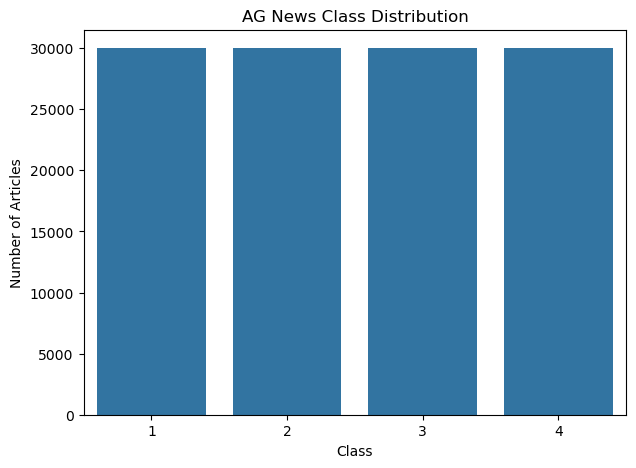

In [16]:
# Class Distribution Graph
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class Index"
)

plt.title("AG News Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Articles")
plt.show()

In [17]:
df["text"] = (
    df["Title"].fillna("") + " " +
    df["Description"].fillna("")
)

df[["Title", "Description", "text"]].head()

,Title,Description,text
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


In [18]:
# Average Sentence/Article Length

df["text_length"] = df["text"].apply(
    lambda x: len(x.split())
)

print(
    "Average article length:",
    df["text_length"].mean()
)

Average article length: 37.84461666666667


In [19]:
# text Preprocessing
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [21]:
df["clean_text"] = df["text"].apply(preprocess_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...


In [22]:
# STEP 13 — Create X and y
X = df["clean_text"].copy()
y = df["Class Index"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (120000,)
y shape: (120000,)


In [23]:
# convert labels
y = y - 1

print("Unique labels:", sorted(y.unique()))

Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [24]:
# STEP 14 — Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 96000
Testing samples: 24000


In [25]:
# STEP 15 — Tokenization
max_words = 15000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Tokenizer fitted successfully")
print("Total vocabulary:", len(tokenizer.word_index))

Tokenizer fitted successfully
Total vocabulary: 57154


In [26]:
#Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Original text:")
print(X_train.iloc[0])

print("\nTokenized sequence:")
print(X_train_seq[0][:30])


Original text:
clijsters unsure about latest injury says hewitt tokyo reuters belgian kim clijsters is unsure about the exact nature of the injury that has prematurely ended her season her fiance lleyton hewitt said on wednesday

Tokenized sequence:
[5214, 12020, 65, 312, 859, 82, 1853, 408, 21, 4177, 3170, 5214, 15, 12020, 65, 2, 9386, 4374, 5, 2, 859, 11, 22, 1, 777, 269, 112, 269, 1, 3444]


In [27]:
# STEP 16 — Padding
max_length = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (96000, 100)
Testing shape: (24000, 100)


In [28]:
# Check one padded sequence
print(X_train_pad[0])

[ 5214 12020    65   312   859    82  1853   408    21  4177  3170  5214
    15 12020    65     2  9386  4374     5     2   859    11    22     1
   777   269   112   269     1  3444  1853    20     9    52     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]


In [29]:
# STEP 17 — Build GRU Model
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=64
    ),
    
    GRU(64),
    
    Dropout(0.3),
    
    Dense(4, activation="softmax")
])

model.build(input_shape=(None, max_length))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 64)             │         960,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 985,220 (3.76 MB)

 Trainable params: 985,220 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# STEP 18 — Compile the Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [31]:
# STEP 19 — Train the Model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 168s 237ms/step - accuracy: 0.2517 - loss: 1.3868 - val_accuracy: 0.2461 - val_loss: 1.3882
Epoch 2/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 195s 289ms/step - accuracy: 0.2523 - loss: 1.3859 - val_accuracy: 0.2463 - val_loss: 1.3860
Epoch 3/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 257s 381ms/step - accuracy: 0.7222 - loss: 0.6380 - val_accuracy: 0.8964 - val_loss: 0.3229


In [32]:
# STEP 20 — Evaluate on Test Data
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9036 - loss: 0.3005
Test Loss: 0.30052852630615234
Test Accuracy: 0.9036250114440918
Test Accuracy (%): 90.36250114440918


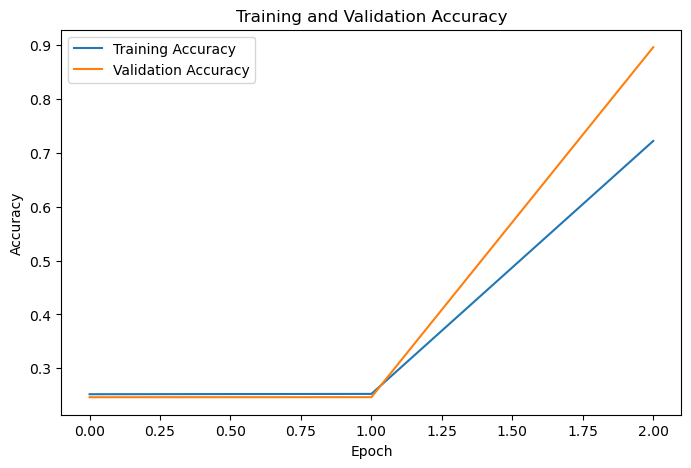

In [33]:
# STEP 21 — Training & Validation Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


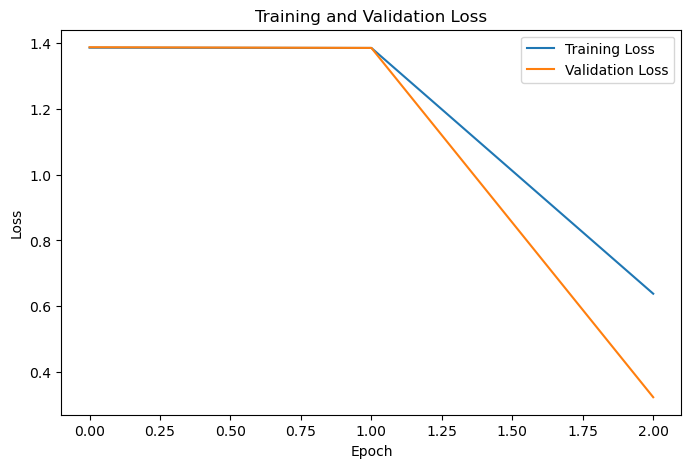

In [34]:
# STEP 22 — Training & Validation Loss Graph

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [35]:
# STEP 23 — Generate Predictions
y_pred_probability = model.predict(X_test_pad)

y_pred = np.argmax(
    y_pred_probability,
    axis=1
)

print("Predictions generated successfully")
print("Prediction shape:", y_pred.shape)

750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step
Predictions generated successfully
Prediction shape: (24000,)


In [36]:
# STEP 24 — Classification Report
class_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       World       0.91      0.89      0.90      6000
      Sports       0.96      0.96      0.96      6000
    Business       0.88      0.86      0.87      6000
    Sci/Tech       0.87      0.90      0.89      6000

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000



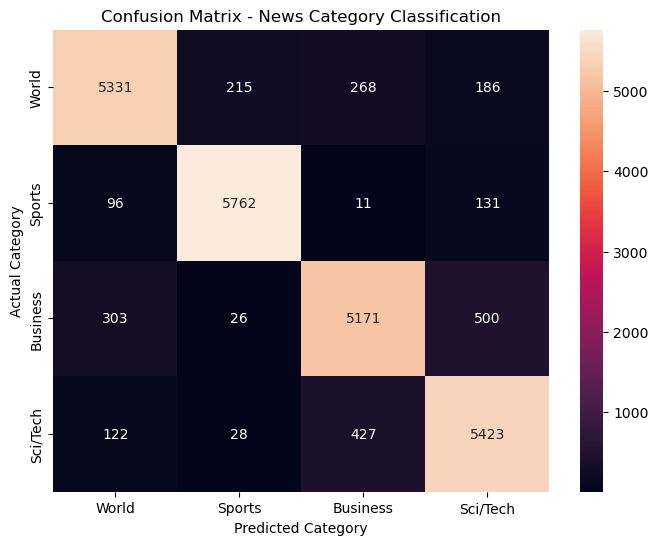

In [37]:
# STEP 25 — Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - News Category Classification")

plt.show()

In [38]:
# STEP 26 — Test on 5 Custom News Inputs
custom_news = [
    "India defeated Australia in the cricket final match.",
    "The company reported a significant increase in its quarterly profits.",
    "The government announced a new international policy agreement.",
    "Google launched a new artificial intelligence technology platform.",
    "The new movie received excellent reviews from audiences."
]

In [39]:
# STEP 27 — Preprocess
clean_custom_news = [
    preprocess_text(text)
    for text in custom_news
]

print(clean_custom_news)

['india defeated australia in the cricket final match', 'the company reported a significant increase in its quarterly profits', 'the government announced a new international policy agreement', 'google launched a new artificial intelligence technology platform', 'the new movie received excellent reviews from audiences']


In [41]:
# STEP 28 — Tokenize and Pad
custom_sequences = tokenizer.texts_to_sequences(
    clean_custom_news
)

custom_padded = pad_sequences(
    custom_sequences,
    maxlen=max_length,
    
    padding="post",
    truncating="post"
)

print("Custom input shape:", custom_padded.shape)

Custom input shape: (5, 100)


In [42]:
# STEP 29 — Predict
custom_probabilities = model.predict(
    custom_padded
)

custom_labels = np.argmax(
    custom_probabilities,
    axis=1
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step


In [43]:
# STEP 30 — Display Predictions
for text, label in zip(
    custom_news,
    custom_labels
):
    print("News:", text)
    print("Predicted Category:", class_names[label])
    print("-" * 60)

News: India defeated Australia in the cricket final match.
Predicted Category: Sports
------------------------------------------------------------
News: The company reported a significant increase in its quarterly profits.
Predicted Category: Business
------------------------------------------------------------
News: The government announced a new international policy agreement.
Predicted Category: World
------------------------------------------------------------
News: Google launched a new artificial intelligence technology platform.
Predicted Category: Sci/Tech
------------------------------------------------------------
News: The new movie received excellent reviews from audiences.
Predicted Category: Sci/Tech
------------------------------------------------------------


In [44]:
# STEP 31 — Save the Final Model 
model.save("news_category_gru_final.keras")

print("Final model saved successfully!")

Final model saved successfully!


In [45]:
# STEP 32 — Save Tokenizer
import pickle

with open("news_category_tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [46]:
# STEP 33 — Final Project Summary
print("========================================")
print("   NEWS CATEGORY CLASSIFICATION")
print("========================================")
print("Dataset          : AG News")
print("Training Samples : 96,000")
print("Testing Samples  : 24,000")
print("Number of Classes: 4")
print("Model            : Embedding + GRU + Dense")
print("Optimizer        : Adam")
print("Test Accuracy    : 90.36%")
print("========================================")
print("Classes:")
print("0 → World")
print("1 → Sports")
print("2 → Business")
print("3 → Sci/Tech")
print("========================================")
print("Model saved as   : news_category_gru_final.keras")
print("Tokenizer saved  : news_category_tokenizer.pkl")
print("========================================")

   NEWS CATEGORY CLASSIFICATION
Dataset          : AG News
Training Samples : 96,000
Testing Samples  : 24,000
Number of Classes: 4
Model            : Embedding + GRU + Dense
Optimizer        : Adam
Test Accuracy    : 90.36%
Classes:
0 → World
1 → Sports
2 → Business
3 → Sci/Tech
Model saved as   : news_category_gru_final.keras
Tokenizer saved  : news_category_tokenizer.pkl
